## Assignment 2

### Data Cleaning and Visualization

**Student Name:** Ayah Abdalmuti

**Student ID:** 1212074

**Section:**  2


### Data Cleaning and Preprocessing
Import Important libraries I will use in code including visualization libraries like seaborn and matplot then Load the Data

In [5]:
# importing numpy, pandas, seaborn and matplot libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Gym_Progress_Dataset_noisy.csv')

# Remove duplicate rows
df = df.drop_duplicates()

# Convert 'Day' column to datetime (handle mixed formats)
df['Day'] = pd.to_datetime(df['Day'], dayfirst=True, errors='coerce')

# Remove rows with invalid dates
df = df.dropna(subset=['Day'])

# Clean Workout_Duration_min column, Remove text and quotes then convert to numeric
df['Workout_Duration_min'] = (
    df['Workout_Duration_min']
    .astype(str)
    .str.replace('"', '')
    .str.replace(' min', '')
)

df['Workout_Duration_min'] = pd.to_numeric(df['Workout_Duration_min'], errors='coerce')

# Handle extreme outliers in Weight_kg (e.g. 658 kg)
df.loc[df['Weight_kg'] > 150, 'Weight_kg'] = np.nan

# Interpolate missing weight values (time-series data)
df['Weight_kg'] = df['Weight_kg'].interpolate()

# Handle missing values in Calories and Protein intake
df['Calories_Intake'] = df['Calories_Intake'].fillna(df['Calories_Intake'].mean())
df['Protein_Intake_g'] = df['Protein_Intake_g'].fillna(df['Protein_Intake_g'].mean())

# Sort data by date
df = df.sort_values('Day').reset_index(drop=True)

# Display the first 5 rows of the cleaned dataset
df.head()

,Day,Weight_kg,Calories_Intake,Protein_Intake_g,Workout_Duration_min,Steps_Walked
0,2025-01-01,71.5,3209,70,41,6820
1,2025-01-02,69.6,2584,150,40,4898
2,2025-01-04,74.6,3216,85,20,2077
3,2025-01-05,69.3,2045,145,24,9577
4,2025-01-06,69.3,2999,86,31,12813


### Question 1:
**Is the person’s weight decreasing over time?**

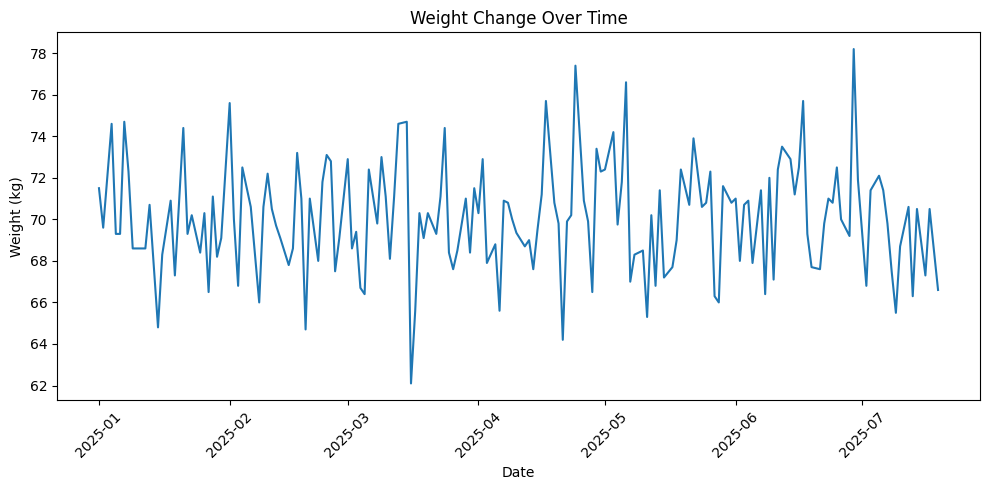

In [6]:
# Plot weight over time to see if it is decreasing
plt.figure(figsize=(10, 5))
plt.plot(df['Day'], df['Weight_kg'])
plt.xlabel('Date')
plt.ylabel('Weight (kg)')
plt.title('Weight Change Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Conclusion:
**The plots show that the person’s weight changes over time with ups and downs. There is no steady decrease, but some periods show weight loss.**

### Question 2: 
**Calculate the weight lost on each day of the week. Identify which weekdays show the highest and lowest weight loss?**

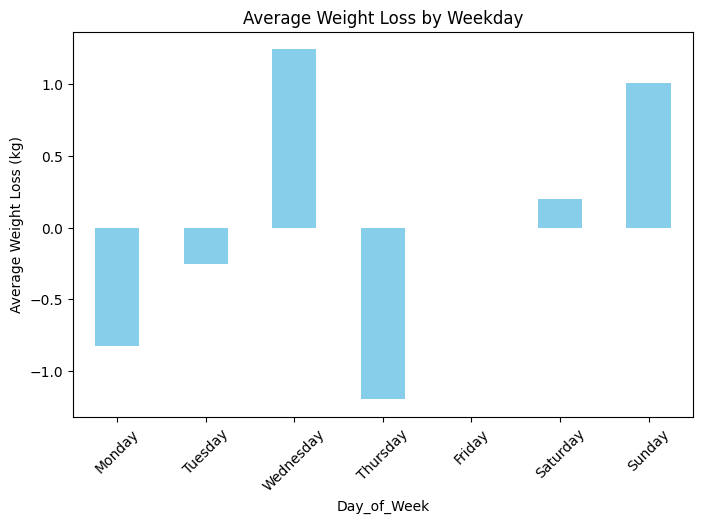

Highest average weight loss: Wednesday (1.24 kg)
Lowest average weight loss: Thursday (-1.20 kg)


In [7]:
# 1. Calculate daily weight change (loss)
df['Weight_Change'] = df['Weight_kg'].diff() * -1  # positive = weight loss

# 2. Add day of the week
df['Day_of_Week'] = df['Day'].dt.day_name()

# 3. Group by weekday and calculate average weight loss
weekly_loss = df.groupby('Day_of_Week')['Weight_Change'].mean()

# 4. Sort weekdays in calendar order
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekly_loss = weekly_loss.reindex(days_order)

# 5. Plot average weight loss per weekday
plt.figure(figsize=(8,5))
weekly_loss.plot(kind='bar', color='skyblue')
plt.ylabel('Average Weight Loss (kg)')
plt.title('Average Weight Loss by Weekday')
plt.xticks(rotation=45)
plt.show()

# 6. Identify weekdays with highest and lowest weight loss
max_day = weekly_loss.idxmax()
min_day = weekly_loss.idxmin()
max_value = weekly_loss.max()
min_value = weekly_loss.min()

print(f"Highest average weight loss: {max_day} ({max_value:.2f} kg)")
print(f"Lowest average weight loss: {min_day} ({min_value:.2f} kg)")

### Conclusion:
**The bar chart shows the average weight lost on each weekday. The person loses the most weight on Wednesday (1.24 kg) and the least on Thursday (-1.20 kg). This means weight loss is not the same every day of the week.**

### Question 3: 
 **Does the person maintain a consistent workout routine throughout the week? Highlight days with unusually high or low workout durations.**

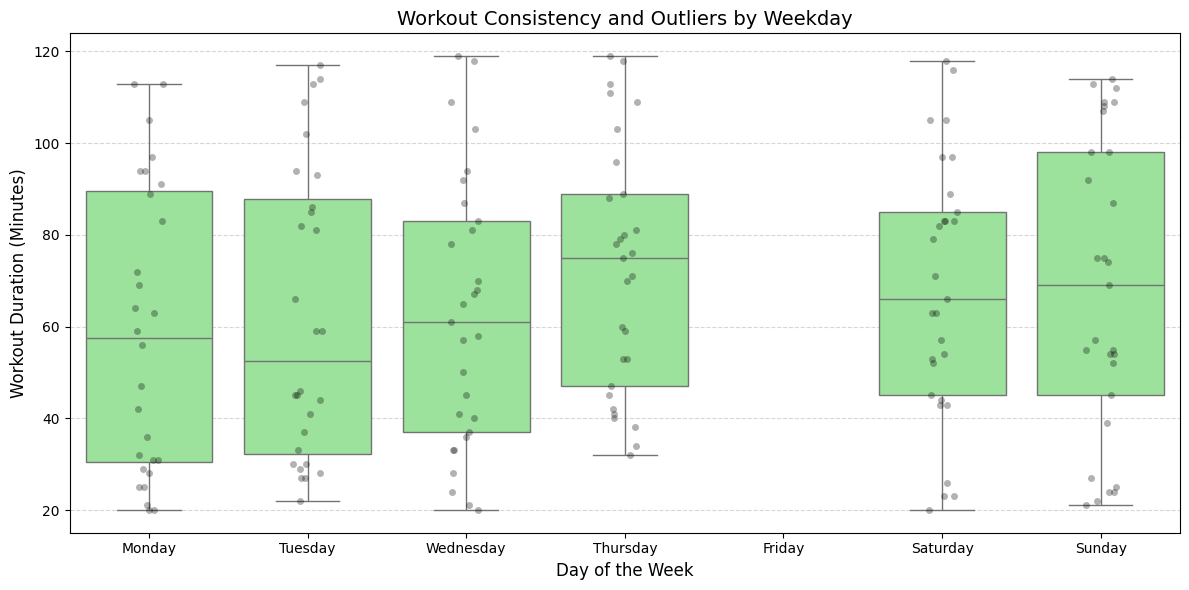

In [8]:
# 1. Define the chronological order of the days
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 2. Set the figure size for better readability
plt.figure(figsize=(12, 6))

# 3. Create the Box Plot to visualize workout duration distribution
sns.boxplot(
    data=df,
    x='Day_of_Week',
    y='Workout_Duration_min',
    order=days_order,
    color='lightgreen'  
)

# 4. Add a Strip Plot on top of the box plot to Shows individual data points and helps identify outliers
sns.stripplot(
    data=df,
    x='Day_of_Week',
    y='Workout_Duration_min',
    order=days_order,
    color='black',
    alpha=0.3
)

# 5. Add title and axis labels
plt.title('Workout Consistency and Outliers by Weekday', fontsize=14)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Workout Duration (Minutes)', fontsize=12)

# 6. Add a horizontal grid for easier value estimation
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 7. Optimize layout and display the plot
plt.tight_layout()
plt.show()

### Conclusion 
**The box plot shows the person’s workout duration for each day of the week. In general, the workouts are somewhat consistent, but there are some unusual days (outliers). For example, some days have very long workouts (like Thursday) and some days have very short workouts (like Monday). This means that most of the time the person follows a routine, but some days are different from the usual.**

### Question 4:
**Analyze whether longer workout sessions correspond to greater weight loss?**

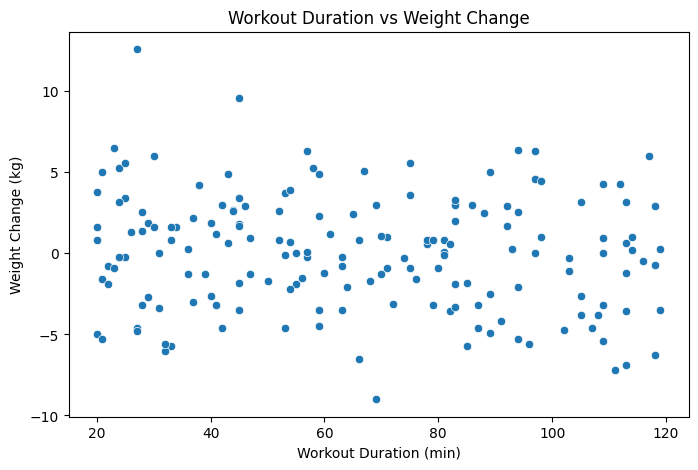

Correlation between workout duration and weight loss: -0.13


In [13]:
# 1. Scatter plot: Workout Duration vs Weight Change
plt.figure(figsize=(8,5))
sns.scatterplot(x='Workout_Duration_min', y='Weight_Change', data=df)
plt.xlabel('Workout Duration (min)')
plt.ylabel('Weight Change (kg)')
plt.title('Workout Duration vs Weight Change')
plt.show()

# 2. Calculate correlation
correlation = df['Workout_Duration_min'].corr(df['Weight_Change'])
print(f"Correlation between workout duration and weight loss: {correlation:.2f}")

### Conclusion: 
**The scatter plot shows no strong pattern between workout duration and weight change. The calculated correlation is -0.13, indicating a very weak negative relationship. This means that longer workouts do not necessarily lead to greater weight loss in this dataset.**
